[![Colabで開く](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/schwalbe1996/ds_media_intro/blob/main/chap12_ex.ipynb)

# 12章 演習問題（宿題）：影のある画像をきれいに白黒にしよう（二値化手法の比較）

このノートブックは 12 章「画像の基本的な処理」の宿題です。所要時間は20分程度です。

このノートブックには **コードの一部しか書かれていません**。`chap12.ipynb` を開いて見ながら、`# TODO` の部分を**自分で埋めて**完成させましょう。「どのセルのコードが使えそうか」を探すことも勉強のうちです。

数独（sudoku）の画像は、撮影時の影や照明ムラのせいで、場所によって紙の白さ・文字の黒さが微妙に異なります。この画像から「文字・枠線」だけをきれいに抜き出す（＝二値化する）には、どの手法が良いでしょうか。3つの二値化手法を比べてみましょう。

## 課題A. 単純閾値法 — 自分で閾値を選ぶ
`chap12.ipynb` の **「単純閾値処理」のセル**（`cv2.threshold(image, t, 255, cv2.THRESH_BINARY)` のセル）と **「ヒストグラム」のセル** を参考に、`# TODO` を埋めましょう。
- まずヒストグラムを表示し、**背景（白）の山と文字（黒）の山の“谷”** を探します。
- その谷あたりの値を **閾値 `t`** に決めて、単純閾値法で二値化します。

## 課題B. 大津の方法 と 適応的閾値処理
`chap12.ipynb` の **「大津の方法」のセル** と **「適応的閾値処理」のセル** を参考に、`# TODO` を埋めましょう。
- 大津の方法は閾値を**自動で**決めてくれます（決まった閾値も表示します）。
- 適応的閾値処理は、**ブロックサイズ `B`（奇数）** と **オフセット `C`** を自分で決めます。`B` や `C` を何通りか変えて、一番文字がきれいに出る値を探しましょう。

**観察と考察:** 単純閾値法・大津の方法・適応的閾値処理の3つを見比べて、
- 問い: **数独画像の文字・枠線を最もきれいに抜き出せたのはどの手法**でしたか？　そして**なぜ**そうなるのかを、「画像の影・照明ムラ」と「画像全体で**単一の閾値**を使うか、場所ごとに**局所的な閾値**を使うか」の違いに結びつけて、2〜3行で説明してください（提出セルの `answer_A` に記入します）。

## 提出方法（重要）
最後の **「提出ファイルの作成」セル** を実行すると、結果画像と考察を1枚にまとめた PDF が自動で作られ、ダウンロードされます。
- ファイル名は **`学籍番号_フルネーム_12.pdf`** になります。氏名は**ローマ字・名+姓・スペースなし**で書きます（例: 彦根太郎 → `TaroHikone`、ファイル名 → `5025123_TaroHikone_12.pdf`）。提出セルの `student_id` と `student_name` を**自分のものに書き換えてから**実行してください。
- 提出するのはこの **PDF 1ファイルだけ** です。

In [1]:
# 画像のダウンロードとライブラリの読み込み（このセルはそのまま実行）
!wget -nc https://github.com/schwalbe1996/ds_media_intro/raw/main/sudoku.png
!pip install -q japanize-matplotlib setuptools  # setuptools は japanize の依存(distutils)対策

import cv2
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib  # PDF内の日本語を表示するため

--2026-06-30 01:48:22--  https://github.com/schwalbe1996/ds_media_intro/raw/main/sudoku.png
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/schwalbe1996/ds_media_intro/main/sudoku.png [following]
--2026-06-30 01:48:22--  https://raw.githubusercontent.com/schwalbe1996/ds_media_intro/main/sudoku.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 285569 (279K) [image/png]
Saving to: ‘sudoku.png’

sudoku.png          100%[===================>] 278.88K  --.-KB/s    in 0.02s   

2026-06-30 01:48:23 (12.3 MB/s) - ‘sudoku.png’ saved [285569/285569]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1

## 課題A：単純閾値法（自分で閾値を選ぶ）

`chap12.ipynb` の「ヒストグラム」のセルと「単純閾値処理」のセルを参考に、`# TODO` を埋めよう。

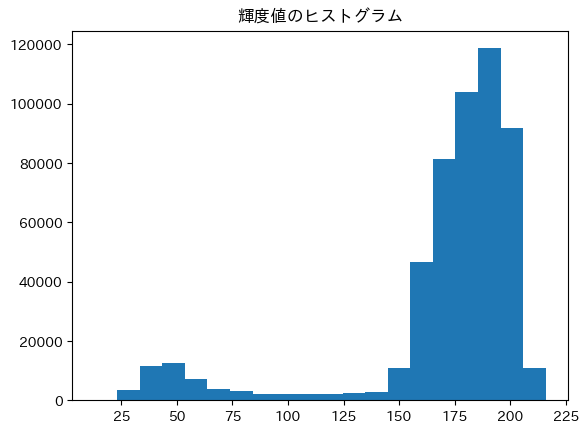

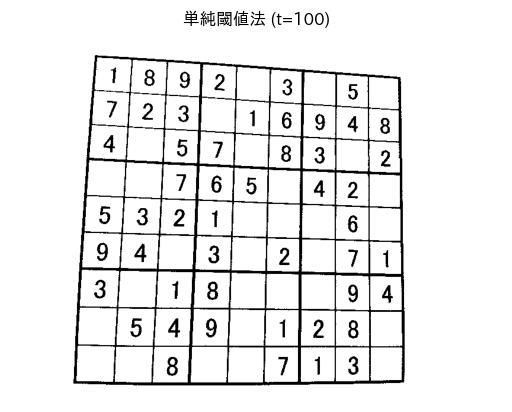

In [2]:
image = cv2.imread('sudoku.png', cv2.IMREAD_GRAYSCALE)

# まず輝度値のヒストグラムを見て、白い背景の山と黒い文字の山の「谷」を探す（このまま実行）
plt.hist(image.flatten(), bins=20)
plt.title('輝度値のヒストグラム')
plt.show()

# TODO: ヒストグラムの谷を参考に、閾値 t を自分で決める
t = 100       # 例: 100 など（数字を入れる）

# TODO: cv2.threshold を使って単純閾値法で二値化し、result_simple に入れる
#        形： ret, result_simple = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)
ret,result_simple = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)

# === ここから下はそのまま実行 ===
plt.imshow(result_simple, cmap='gray')
plt.title(f'単純閾値法 (t={t})')
plt.axis('off')
plt.show()

## 課題B：大津の方法 と 適応的閾値処理

`chap12.ipynb` の「大津の方法」のセルと「適応的閾値処理」のセルを参考に、`# TODO` を埋めよう。

大津の方法で決まった閾値: 120.0


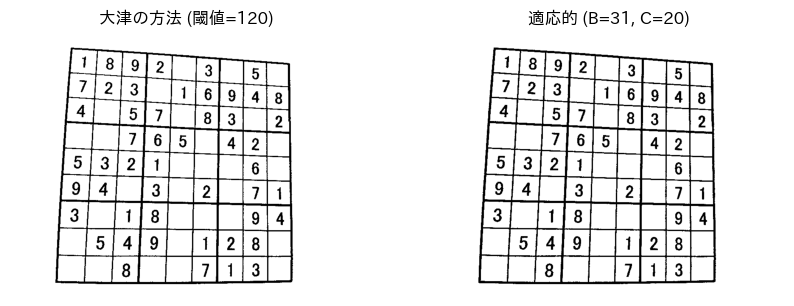

In [3]:
# --- 大津の方法（閾値を自動で決める） ---
# TODO: cv2.threshold に cv2.THRESH_BINARY+cv2.THRESH_OTSU を指定して二値化し、result_otsu に入れる
#        形： ret_otsu, result_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ret_otsu,result_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print('大津の方法で決まった閾値:', ret_otsu)

# --- 適応的閾値処理（場所ごとに閾値を変える） ---
# TODO: ブロックサイズ B（必ず奇数）とオフセット C を自分で決める
B = 31         # 例: 25 （奇数にすること）
C = 20         # 例: 10

# TODO: cv2.adaptiveThreshold を使って二値化し、result_adaptive に入れる
#        形： result_adaptive = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, B, C)
result_adaptive = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, B, C)

# === ここから下はそのまま実行 ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(result_otsu, cmap='gray'); plt.title(f'大津の方法 (閾値={ret_otsu:.0f})'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(result_adaptive, cmap='gray'); plt.title(f'適応的 (B={B}, C={C})'); plt.axis('off')
plt.show()

## 提出ファイルの作成

下の `student_id`・`student_name`・`answer_A` を書き換えてから実行すると、提出用 PDF が作られてダウンロードされます。**この PDF 1ファイルだけ** を提出してください。

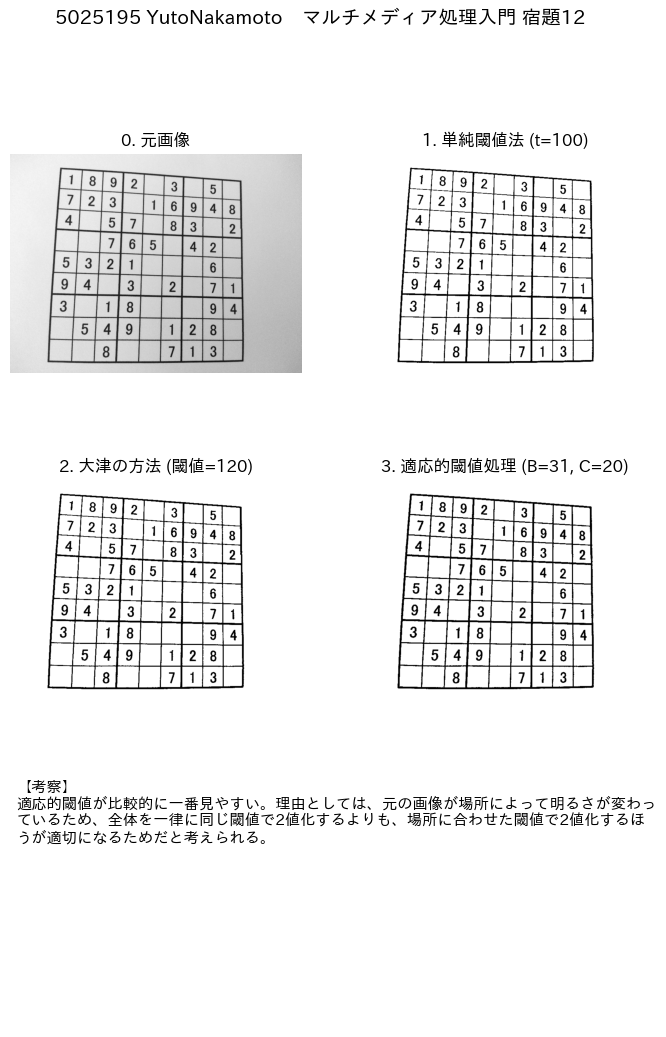

保存しました: 5025195_YutoNakamoto_12.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import matplotlib.gridspec as gridspec

# ★ 自分の情報に書き換える ★
student_id   = "5025195"             # 学籍番号（7桁）
student_name = "YutoNakamoto"          # フルネーム（ローマ字・名+姓・スペースなし。例: 彦根太郎→TaroHikone）
# 考察は下の3連引用符（"""）と """ の間に書く（改行して複数行でも、長い一文でもよい。自動で折り返される）
answer_A = """適応的閾値が比較的に一番見やすい。理由としては、元の画像が場所によって明るさが変わっているため、全体を一律に同じ閾値で2値化するよりも、場所に合わせた閾値で2値化するほうが適切になるためだと考えられる。"""

# === ここから下はそのまま実行 ===
def wrap_jp(text, width=42):
    """日本語は空白がなく自動折り返しが効かないため、width文字ごとに改行を入れる（明示的な改行は保持）"""
    out = []
    for para in text.split("\n"):
        if para == "":
            out.append("")
        else:
            out += [para[i:i+width] for i in range(0, len(para), width)]
    return "\n".join(out)

fig = plt.figure(figsize=(8.27, 11.69))  # A4縦
gs = gridspec.GridSpec(3, 2, height_ratios=[1.1, 1.1, 1])
fig.suptitle(f"{student_id} {student_name}　マルチメディア処理入門 宿題12", fontsize=14)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(image, cmap='gray'); ax1.set_title("0. 元画像"); ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(result_simple, cmap='gray'); ax2.set_title(f"1. 単純閾値法 (t={t})"); ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 0])
ax3.imshow(result_otsu, cmap='gray'); ax3.set_title(f"2. 大津の方法 (閾値={ret_otsu:.0f})"); ax3.axis('off')

ax4 = fig.add_subplot(gs[1, 1])
ax4.imshow(result_adaptive, cmap='gray'); ax4.set_title(f"3. 適応的閾値処理 (B={B}, C={C})"); ax4.axis('off')

ax5 = fig.add_subplot(gs[2, :]); ax5.axis('off')
ax5.text(0.01, 0.99, "【考察】\n" + wrap_jp(answer_A), va='top', ha='left', fontsize=11)

filename = f"{student_id}_{student_name}_12.pdf"
fig.savefig(filename, bbox_inches='tight')
plt.show()
print("保存しました:", filename)

# Colab なら自動でダウンロード
try:
    from google.colab import files
    files.download(filename)
except Exception:
    print("（Colab 以外では自動ダウンロードされません。左のファイル一覧から取得してください）")